In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_colwidth', 100)

In [2]:
df = pd.read_csv(r"D:\NLP project\datasets\Reviews.csv")

In [3]:
df.shape

(568454, 10)

In [4]:
df.columns

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='object')

In [7]:
df.isna().sum()

Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64

In [6]:
df.isna().sum().sum()

np.int64(53)

In [5]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.dtypes

Id                         int64
ProductId                 object
UserId                    object
ProfileName               object
HelpfulnessNumerator       int64
HelpfulnessDenominator     int64
Score                      int64
Time                       int64
Summary                   object
Text                      object
dtype: object

In [3]:
# Check duplicate reviews (same user, same product, same text)
duplicates = df.duplicated(subset=['UserId', 'ProfileName', 'Time', 'Text'])
print(f"Total duplicate rows: {duplicates.sum()}")

Total duplicate rows: 174521


In [4]:
# Remove duplicates
df = df.drop_duplicates(subset=['UserId', 'ProfileName', 'Time', 'Text'])

# Fill nulls instead of dropping
df['ProfileName'] = df['ProfileName'].fillna('Unknown')
df['Summary'] = df['Summary'].fillna('')

# Confirm cleaned shape
print(f"Cleaned dataset shape: {df.shape}")


Cleaned dataset shape: (393933, 10)


In [5]:
df.duplicated(subset=['Text']).sum()

np.int64(354)

In [6]:
df = df.drop_duplicates(subset=['Text'])

C:\Users\pragy\AppData\Local\Temp\ipykernel_24396\4143457182.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Score', data=df, palette='viridis')


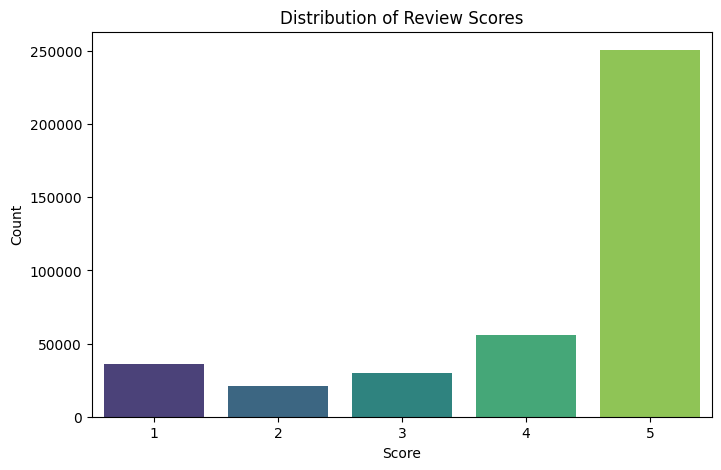

Score
5    250716
4     56042
1     36275
3     29754
2     20792
Name: count, dtype: int64


In [7]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Score', data=df, palette='viridis')
plt.title('Distribution of Review Scores')
plt.xlabel('Score')
plt.ylabel('Count')
plt.show()

# Exact numbers
print(df['Score'].value_counts())

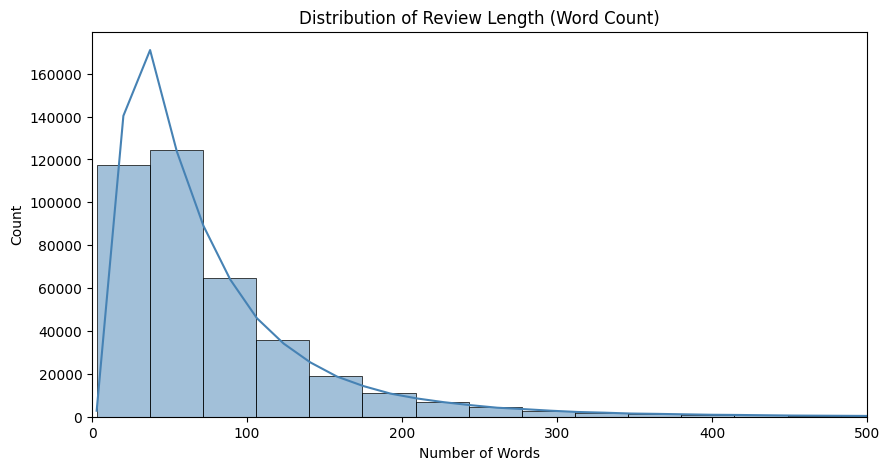

count    393579.000000
mean         79.753079
std          77.162402
min           3.000000
25%          34.000000
50%          57.000000
75%          97.000000
max        3432.000000
Name: review_length, dtype: float64


In [8]:
# Add a column for review length
df['review_length'] = df['Text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 5))
sns.histplot(df['review_length'], bins=100, kde=True, color='steelblue')
plt.title('Distribution of Review Length (Word Count)')
plt.xlabel('Number of Words')
plt.ylabel('Count')
plt.xlim(0, 500)
plt.show()

print(df['review_length'].describe())

C:\Users\pragy\AppData\Local\Temp\ipykernel_24396\1826959711.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Score', y='review_length', data=df, palette='viridis')


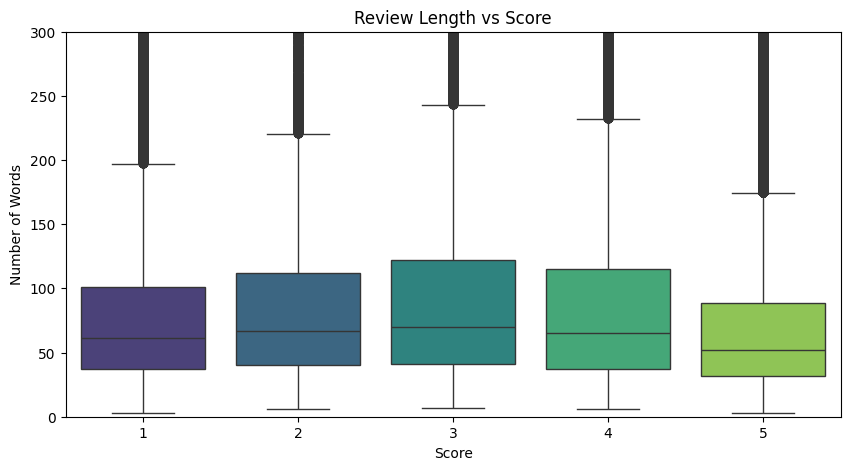

In [9]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='Score', y='review_length', data=df, palette='viridis')
plt.title('Review Length vs Score')
plt.xlabel('Score')
plt.ylabel('Number of Words')
plt.ylim(0, 300)
plt.show()

"Negative reviews (1–2 star) tend to be longer and more detailed than positive reviews (5 star), suggesting dissatisfied customers provide richer feedback for product improvement."

In [14]:
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,review_length
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned dog food products and have found them all to be of ...,48
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanuts...the peanuts were actually small sized unsalted...,31
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all","This is a confection that has been around a few centuries. It is a light, pillowy citrus gelati...",94
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient in Robitussin I believe I have found it. I got thi...,41
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wide assortment of yummy taffy. Delivery was very qu...,27


Score
1    0.411994
2    0.372350
3    0.356139
4    0.387938
5    0.436352
Name: helpfulness_ratio, dtype: float64


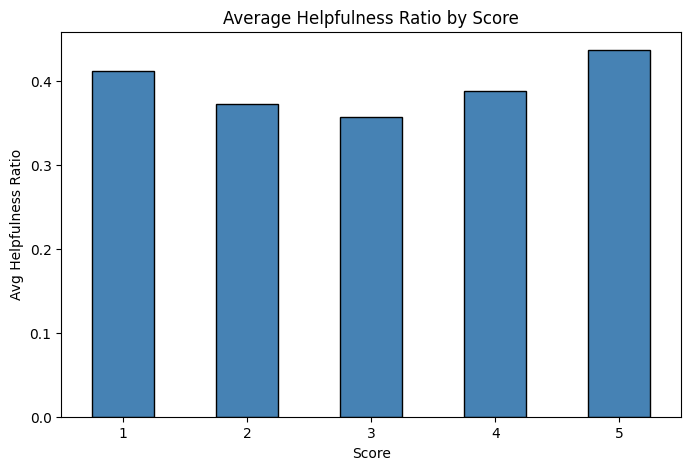

In [10]:
# Calculate helpfulness ratio (avoid division by zero)
df['helpfulness_ratio'] = df.apply(
    lambda x: x['HelpfulnessNumerator'] / x['HelpfulnessDenominator']
    if x['HelpfulnessDenominator'] > 0 else 0, axis=1
)

# Average helpfulness by score
helpfulness_by_score = df.groupby('Score')['helpfulness_ratio'].mean()
print(helpfulness_by_score)

plt.figure(figsize=(8, 5))
helpfulness_by_score.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Average Helpfulness Ratio by Score')
plt.xlabel('Score')
plt.ylabel('Avg Helpfulness Ratio')
plt.xticks(rotation=0)
plt.show()



"Readers find extreme reviews (1 and 5 star) significantly more helpful than neutral ones, suggesting polarised opinions drive purchase decisions more than balanced assessments."

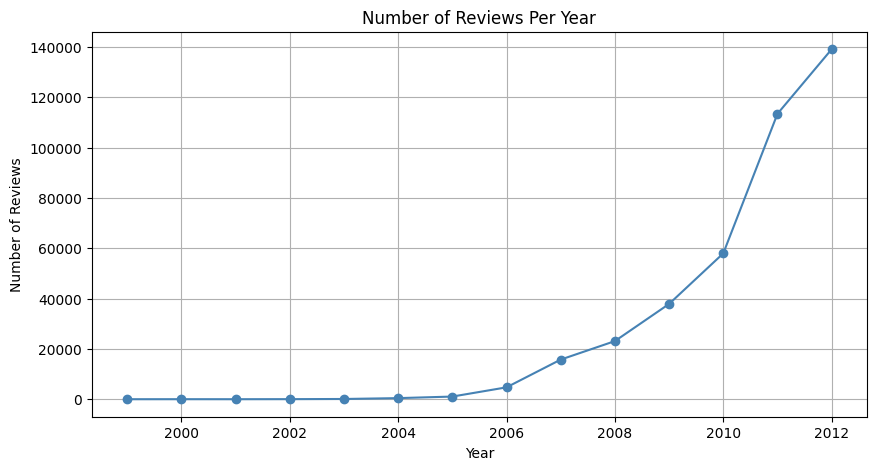

Year
1999         4
2000        17
2001         8
2002        33
2003        99
2004       439
2005      1059
2006      4722
2007     15752
2008     23100
2009     37866
2010     57967
2011    113428
2012    139085
dtype: int64


In [11]:
# Convert Unix timestamp to datetime
df['Time'] = pd.to_datetime(df['Time'], unit='s')
df['Year'] = df['Time'].dt.year

# Reviews per year
reviews_per_year = df.groupby('Year').size()

plt.figure(figsize=(10, 5))
reviews_per_year.plot(kind='line', marker='o', color='steelblue')
plt.title('Number of Reviews Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Reviews')
plt.grid(True)
plt.show()

print(reviews_per_year)

"Amazon Fine Food review volume grew exponentially — from just 4 reviews in 1999 to 139,186 in 2012 — reflecting the broader shift in consumer behaviour toward online product research before purchase."

In [19]:
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,review_length,helpfulness_ratio,Year
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,2011-04-27,Good Quality Dog Food,I have bought several of the Vitality canned dog food products and have found them all to be of ...,48,1.0,2011
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,2012-09-07,Not as Advertised,Product arrived labeled as Jumbo Salted Peanuts...the peanuts were actually small sized unsalted...,31,0.0,2012
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,2008-08-18,"""Delight"" says it all","This is a confection that has been around a few centuries. It is a light, pillowy citrus gelati...",94,1.0,2008
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,2011-06-13,Cough Medicine,If you are looking for the secret ingredient in Robitussin I believe I have found it. I got thi...,41,1.0,2011
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,2012-10-21,Great taffy,Great taffy at a great price. There was a wide assortment of yummy taffy. Delivery was very qu...,27,0.0,2012


In [ ]:
import spacy
from tqdm import tqdm

# Load SpaCy model
nlp = spacy.load('en_core_web_sm')

# Disable unnecessary pipeline components for speed
nlp.disable_pipes(['parser', 'ner'])

# Negation words to always keep
negation_words = {
    'not', 'no', 'never', 'neither', 'nobody', 'nothing',
    'nowhere', 'nor', "don't", "doesn't", "didn't", "won't",
    "wouldn't", "couldn't", "shouldn't", "isn't", "aren't",
    "wasn't", "weren't", "haven't", "hasn't", "hadn't", "cannot"
}

# Updated stopwords — remove negation words from stoplist
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')
stop_words = set(stopwords.words('english')) - negation_words

def lemmatize_batch(texts, batch_size=500):
    results = []
    for doc in nlp.pipe(texts, batch_size=batch_size):
        tokens = [
            token.lemma_.lower()
            for token in doc
            if not token.is_stop        # remove stopwords
            and not token.is_punct      # remove punctuation
            and not token.is_space      # remove spaces
            and len(token.text) > 2     # remove very short tokens
            and token.lemma_.lower() not in stop_words
        ]
        results.append(' '.join(tokens))
    return results

# Process in batches of 1000 to avoid RAM crash
batch_size = 1000
texts = df['Text'].astype(str).tolist()
lemmatized = []

print(f"Total reviews to process: {len(texts)}")

for i in range(0, len(texts), batch_size):
    batch = texts[i:i+batch_size]
    lemmatized.extend(lemmatize_batch(batch))
    if i % 10000 == 0:
        print(f"Processed {i}/{len(texts)}...")

df['lemmatized_text'] = lemmatized
print("Lemmatization complete!")
print(df['lemmatized_text'].iloc[0][:200]) 

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\pragy\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Total reviews to process: 393579
Processed 0/393579...
Processed 10000/393579...
Processed 20000/393579...
Processed 30000/393579...
Processed 40000/393579...
Processed 50000/393579...
Processed 60000/393579...
Processed 70000/393579...
Processed 80000/393579...
Processed 90000/393579...
Processed 100000/393579...
Processed 110000/393579...
Processed 120000/393579...
Processed 130000/393579...
Processed 140000/393579...
Processed 150000/393579...
Processed 160000/393579...
Processed 170000/393579...
Processed 180000/393579...
Processed 190000/393579...
Processed 200000/393579...
Processed 210000/393579...
Processed 220000/393579...
Processed 230000/393579...
Processed 240000/393579...
Processed 250000/393579...
Processed 260000/393579...
Processed 270000/393579...
Processed 280000/393579...
Processed 290000/393579...
Processed 300000/393579...
Processed 310000/393579...
Processed 320000/393579...
Processed 330000/393579...
Processed 340000/393579...
Processed 350000/393579...
Processed

In [13]:
df.to_csv('Reviews_lemmatized.csv', index=False)
print("Saved successfully!")
print(df.shape)

Saved successfully!
(393579, 14)


In [15]:
df = pd.read_csv("Reviews_lemmatized.csv")

print("Data loaded successfully!")
print(df.shape)
df.head()

Data loaded successfully!
(393579, 14)


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,review_length,helpfulness_ratio,Year,lemmatized_text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,2011-04-27,Good Quality Dog Food,I have bought several of the Vitality canned dog food products and have found them all to be of ...,48,1.0,2011,buy vitality dog food product find good quality product look like stew process meat smell well l...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,2012-09-07,Not as Advertised,Product arrived labeled as Jumbo Salted Peanuts...the peanuts were actually small sized unsalted...,31,0.0,2012,product arrive label jumbo salted peanuts peanut actually small sized unsalte sure error vendor ...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,2008-08-18,"""Delight"" says it all","This is a confection that has been around a few centuries. It is a light, pillowy citrus gelati...",94,1.0,2008,confection century light pillowy citrus gelatin nut case filbert cut tiny square liberally coat ...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,2011-06-13,Cough Medicine,If you are looking for the secret ingredient in Robitussin I believe I have found it. I got thi...,41,1.0,2011,look secret ingredient robitussin believe find get addition root beer extract order good cherry ...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,2012-10-21,Great taffy,Great taffy at a great price. There was a wide assortment of yummy taffy. Delivery was very qu...,27,0.0,2012,great taffy great price wide assortment yummy taffy delivery quick taffy lover deal


C:\Users\pragy\AppData\Local\Temp\ipykernel_24396\1157037744.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='ReviewCount', y='ProductId',


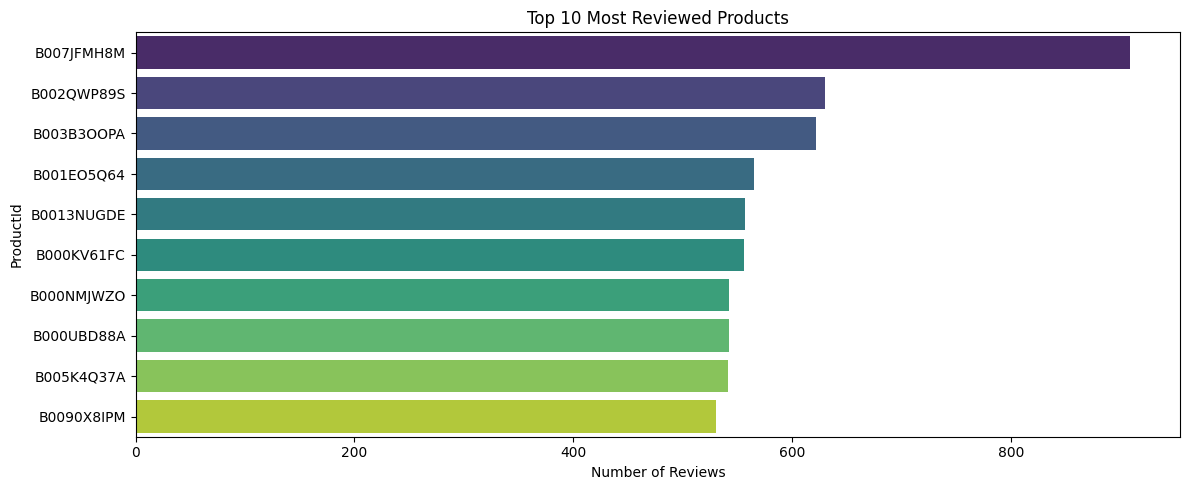

    ProductId  ReviewCount
0  B007JFMH8M          909
1  B002QWP89S          630
2  B003B3OOPA          622
3  B001EO5Q64          565
4  B0013NUGDE          557
5  B000KV61FC          556
6  B000NMJWZO          542
7  B000UBD88A          542
8  B005K4Q37A          541
9  B0090X8IPM          530


In [16]:
# Top 10 most reviewed products
top_products = df['ProductId'].value_counts().head(10).reset_index()
top_products.columns = ['ProductId', 'ReviewCount']

plt.figure(figsize=(12, 5))
sns.barplot(x='ReviewCount', y='ProductId', 
            data=top_products, palette='viridis')
plt.title('Top 10 Most Reviewed Products')
plt.xlabel('Number of Reviews')
plt.tight_layout()
plt.show()

print(top_products)

C:\Users\pragy\AppData\Local\Temp\ipykernel_24396\2823152475.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='ReviewCount', y='UserId',


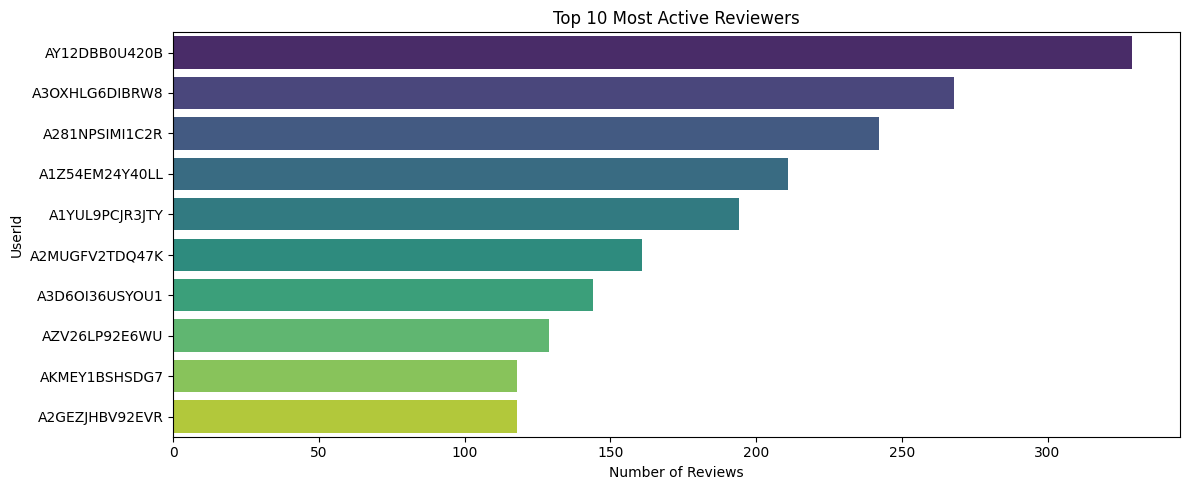

           UserId  ReviewCount
0   AY12DBB0U420B          329
1  A3OXHLG6DIBRW8          268
2  A281NPSIMI1C2R          242
3  A1Z54EM24Y40LL          211
4  A1YUL9PCJR3JTY          194
5  A2MUGFV2TDQ47K          161
6  A3D6OI36USYOU1          144
7   AZV26LP92E6WU          129
8   AKMEY1BSHSDG7          118
9  A2GEZJHBV92EVR          118


In [17]:
# Top 10 most active reviewers
top_users = df['UserId'].value_counts().head(10).reset_index()
top_users.columns = ['UserId', 'ReviewCount']

plt.figure(figsize=(12, 5))
sns.barplot(x='ReviewCount', y='UserId',
            data=top_users, palette='viridis')
plt.title('Top 10 Most Active Reviewers')
plt.xlabel('Number of Reviews')
plt.tight_layout()
plt.show()

print(top_users)

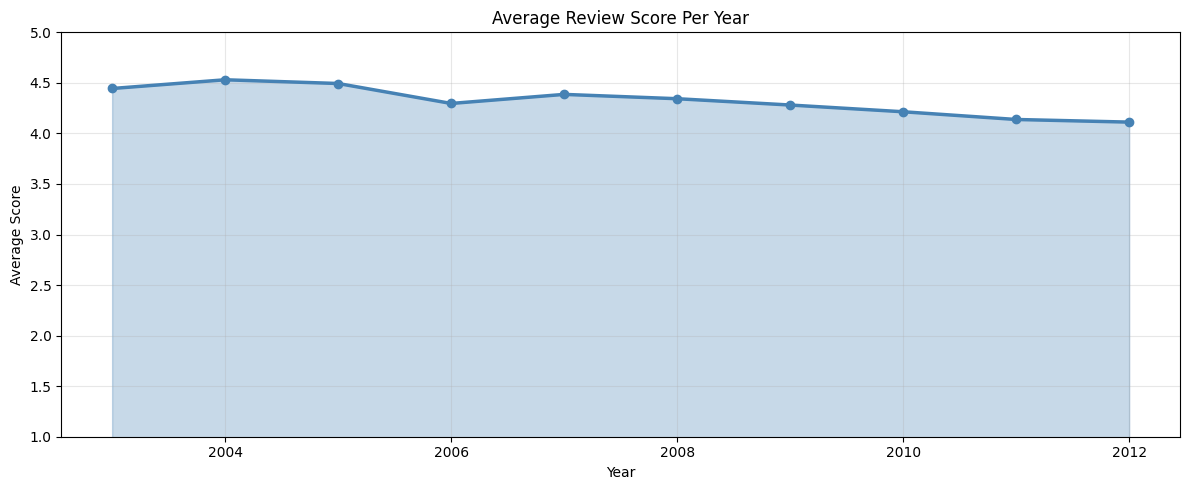

    Year     Score
4   2003  4.444444
5   2004  4.530752
6   2005  4.493862
7   2006  4.296485
8   2007  4.386173
9   2008  4.343377
10  2009  4.280991
11  2010  4.214363
12  2011  4.137964
13  2012  4.112039


In [18]:
avg_score_year = df.groupby('Year')['Score'].mean().reset_index()
avg_score_year = avg_score_year[avg_score_year['Year'] >= 2003]

plt.figure(figsize=(12, 5))
plt.plot(avg_score_year['Year'], avg_score_year['Score'],
         marker='o', color='steelblue', linewidth=2.5)
plt.fill_between(avg_score_year['Year'], avg_score_year['Score'],
                 alpha=0.3, color='steelblue')
plt.title('Average Review Score Per Year')
plt.xlabel('Year')
plt.ylabel('Average Score')
plt.ylim(1, 5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(avg_score_year)

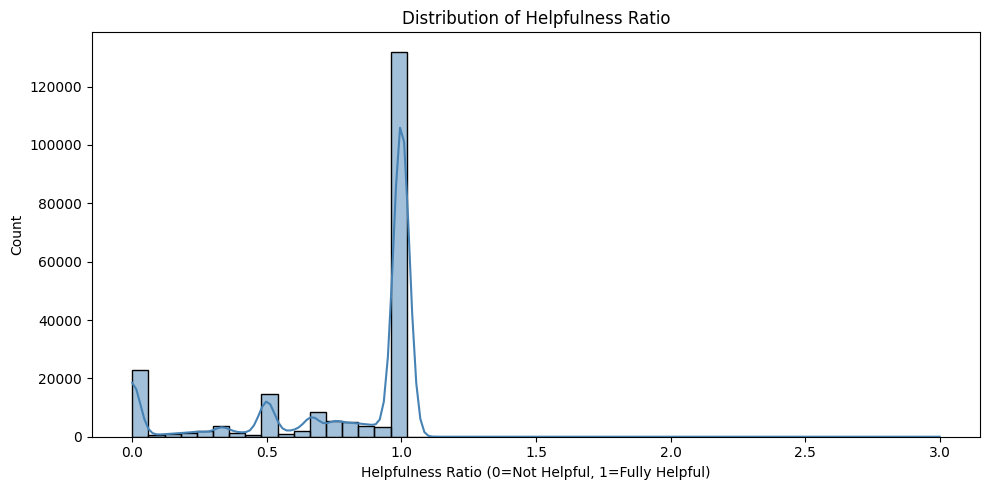

count    209083.000000
mean          0.786409
std           0.341176
min           0.000000
25%           0.666667
50%           1.000000
75%           1.000000
max           3.000000
Name: helpfulness_ratio, dtype: float64


In [19]:
# Only reviews that have been voted on
df_voted = df[df['HelpfulnessDenominator'] > 0].copy()
df_voted['helpfulness_ratio'] = (
    df_voted['HelpfulnessNumerator'] / df_voted['HelpfulnessDenominator']
)

plt.figure(figsize=(10, 5))
sns.histplot(df_voted['helpfulness_ratio'], bins=50, 
             color='steelblue', kde=True)
plt.title('Distribution of Helpfulness Ratio')
plt.xlabel('Helpfulness Ratio (0=Not Helpful, 1=Fully Helpful)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print(df_voted['helpfulness_ratio'].describe())

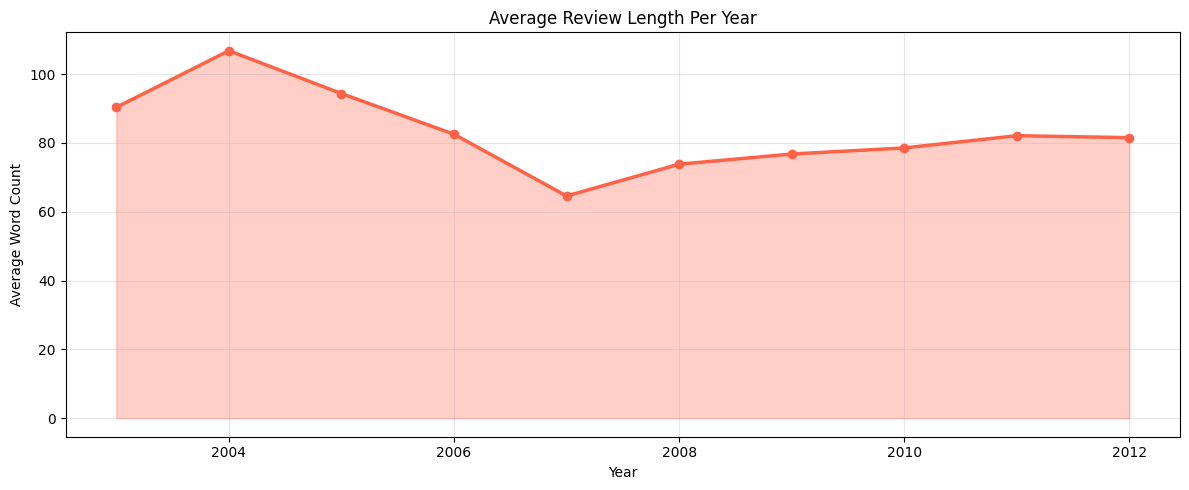

In [20]:
length_by_year = df[df['Year'] >= 2003].groupby('Year')['review_length'].mean().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(length_by_year['Year'], length_by_year['review_length'],
         marker='o', color='tomato', linewidth=2.5)
plt.fill_between(length_by_year['Year'], length_by_year['review_length'],
                 alpha=0.3, color='tomato')
plt.title('Average Review Length Per Year')
plt.xlabel('Year')
plt.ylabel('Average Word Count')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

C:\Users\pragy\AppData\Local\Temp\ipykernel_24396\1586425088.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot = df_voted.groupby(


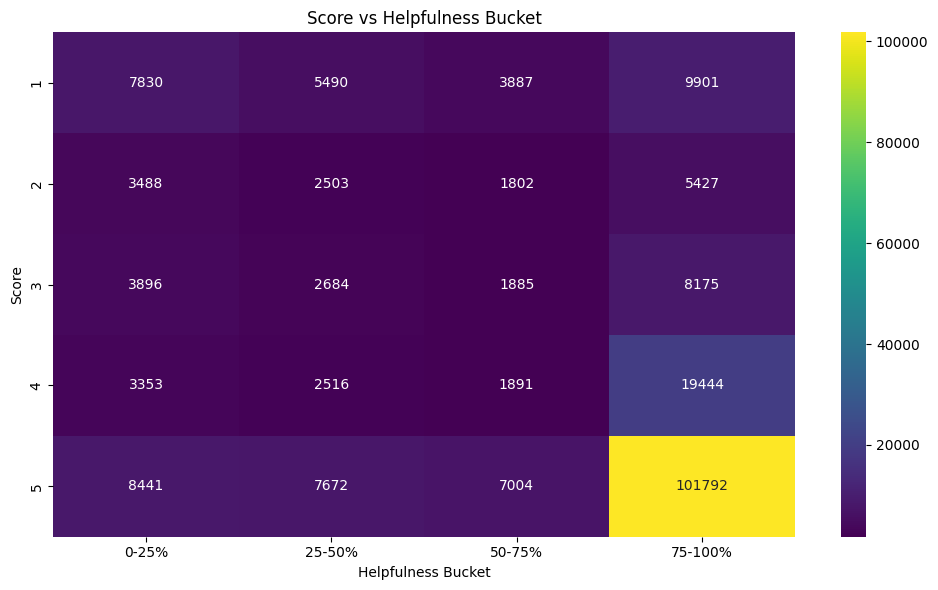

In [21]:
# Pivot table of score vs helpfulness bucket
df_voted['helpful_bucket'] = pd.cut(
    df_voted['helpfulness_ratio'],
    bins=[0, 0.25, 0.5, 0.75, 1.0],
    labels=['0-25%', '25-50%', '50-75%', '75-100%'],
    include_lowest=True
)

pivot = df_voted.groupby(
    ['Score', 'helpful_bucket']
).size().unstack(fill_value=0)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='d', cmap='viridis')
plt.title('Score vs Helpfulness Bucket')
plt.xlabel('Helpfulness Bucket')
plt.ylabel('Score')
plt.tight_layout()
plt.show()

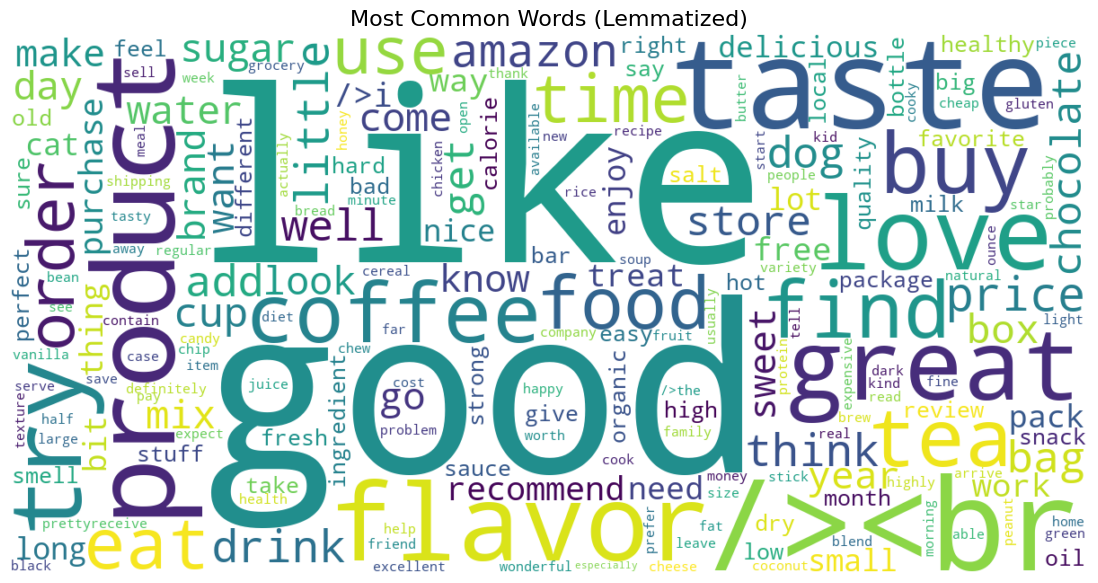

In [14]:
from collections import Counter
from wordcloud import WordCloud

counter = Counter()
for text in df['lemmatized_text'].dropna():
    words = str(text).split()
    counter.update(words)

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    max_words=200,
    colormap='viridis'
).generate_from_frequencies(counter)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words (Lemmatized)', fontsize=16)
plt.show()

In [12]:
import re

def clean_text(text):
    text = str(text)
    text = re.sub(r'<.*?>', ' ', text)        # Remove HTML tags like <br>
    text = re.sub(r'&amp;|&lt;|&gt;', ' ', text)  # Remove HTML entities
    text = re.sub(r'[^a-zA-Z\s]', '', text)   # Remove punctuation & numbers
    text = text.lower().strip()                # Lowercase & trim whitespace
    text = re.sub(r'\s+', ' ', text)           # Remove extra spaces
    return text

# Apply to both Text and Summary columns
df['cleaned_text'] = df['Text'].apply(clean_text)
df['cleaned_summary'] = df['Summary'].apply(clean_text)

# Verify - compare before and after
print("BEFORE:", df['Text'].iloc[0][:200])
print("\nAFTER:", df['cleaned_text'].iloc[0][:200])

BEFORE: I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than a processed meat and it smells better. My Labrador

AFTER: i have bought several of the vitality canned dog food products and have found them all to be of good quality the product looks more like a stew than a processed meat and it smells better my labrador i


In [22]:
import re

def clean_lemmatized(text):
    text = str(text)
    
    # Remove any leftover HTML (rare but safe)
    text = re.sub(r'<.*?>', ' ', text)
    
    # Remove any non-letter characters (extra safety)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Apply on lemmatized text (NOT raw Text)
df['final_text'] = df['lemmatized_text'].apply(clean_lemmatized)

print("Before:", df['lemmatized_text'].iloc[0][:200])
print("\nAfter:", df['final_text'].iloc[0][:200])

Before: buy vitality dog food product find good quality product look like stew process meat smell well labrador finicky appreciate product well

After: buy vitality dog food product find good quality product look like stew process meat smell well labrador finicky appreciate product well


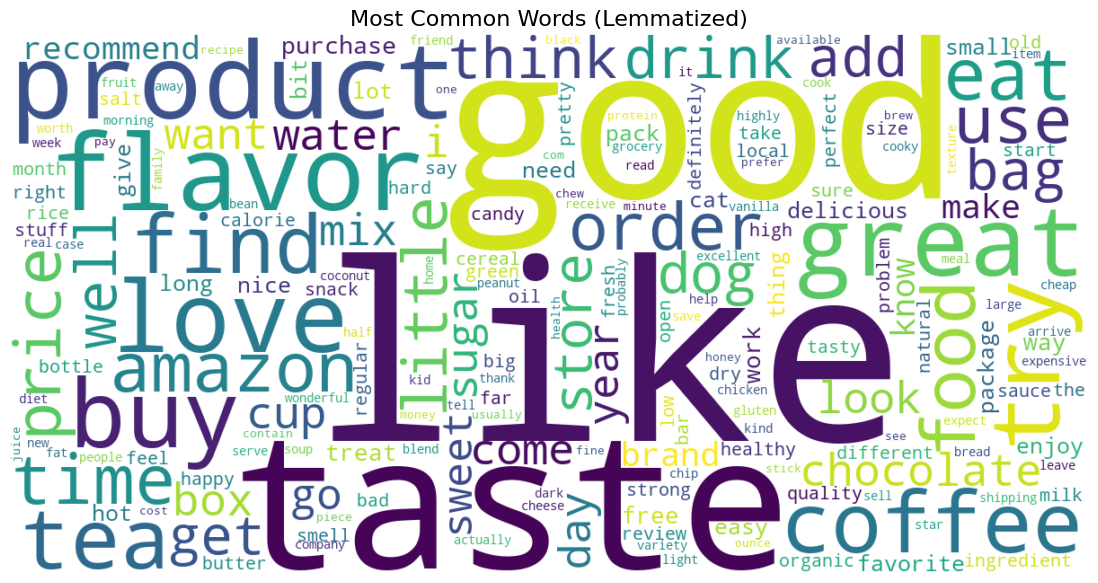

In [23]:
from collections import Counter
from wordcloud import WordCloud

counter = Counter()
for text in df['final_text'].dropna():
    words = str(text).split()
    counter.update(words)

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    max_words=200,
    colormap='viridis'
).generate_from_frequencies(counter)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words (Lemmatized)', fontsize=16)
plt.show()

br is completely gone ✅ — but now notice something new. Look at the biggest words:

In [ ]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = text.split()
    filtered = [w for w in words if w not in stop_words]
    return ' '.join(filtered)

df['cleaned_text'] = df['cleaned_text'].apply(remove_stopwords)
df['cleaned_summary'] = df['cleaned_summary'].apply(remove_stopwords)

# Verify
print("AFTER STOPWORD REMOVAL:", df['cleaned_text'].iloc[0][:200])

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\pragy\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


AFTER STOPWORD REMOVAL: bought several vitality canned dog food products found good quality product looks like stew processed meat smells better labrador finicky appreciates product better


now this NLTK removal is not required as already SpaCy+lemmatization done 
You already removed stopwords during SpaCy preprocessing

In [26]:

from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

def get_top_ngrams(texts, n=2, top_k=50):
    vec = CountVectorizer(ngram_range=(n,n), min_df=5)
    X = vec.fit_transform(texts)
    
    counts = X.sum(axis=0).A1
    words = vec.get_feature_names_out()
    
    df_ngrams = pd.DataFrame({'ngram': words, 'count': counts})
    return df_ngrams.sort_values(by='count', ascending=False).head(top_k)
get_top_ngrams(df['final_text'], n=2)

,ngram,count
317773,taste like,23460
152475,highly recommend,12843
317513,taste good,12789
143388,grocery store,12708
134981,gluten free,12393
7999,amazon com,11156
317534,taste great,10644
231297,peanut butter,9490
142708,green tea,9235
91329,dog food,7734


In [27]:
custom_stopwords = {
    'http', 'www', 'com', 'href',
    'look', 'feel', 'make', 'use', 'get',
    'thing', 'time', 'year', 'day',
    'bit', 'lot'
}

def refine_text(text):
    words = text.split()
    return ' '.join([w for w in words if w not in custom_stopwords])

df['refined_text'] = df['final_text'].apply(refine_text)

In [28]:
get_top_ngrams(df['refined_text'], n=2)

,ngram,count
311651,taste like,24170
311386,taste good,12897
148634,highly recommend,12843
139540,grocery store,12708
131029,gluten free,12393
311408,taste great,10694
225072,peanut butter,9490
138880,green tea,9236
89076,dog food,7748
8506,amazon product,7480


What improved after your refinement
1. Noise is gone

Earlier you had:

http www ❌
href http ❌
com product ❌

Now:
Completely removed → perfect

2. Cleaner, meaningful phrases

Now your top bigrams are:

 Sentiment-driven
highly recommend
great product
good price
high quality
absolutely love

These are strong sentiment indicators

Product-based insights
dog food
cat food
green tea
olive oil
dark chocolate
ice cream

Shows:

Your dataset is multi-domain consumer product reviews

Taste / quality focus (VERY IMPORTANT)
taste good
taste great
great taste
good flavor

KEY INSIGHT:

Customers care heavily about taste & flavor

 Purchase behavior
buy product
order amazon
free shipping
subscribe save

 Insight:
Buying experience is also discussed

In [29]:

# Top trigrams
print(get_top_ngrams(df['refined_text'].dropna(), n=3))

                           ngram  count
80581        local grocery store   3092
65187          health food store   1651
52241        fructose corn syrup   1590
66354         high fructose corn   1584
66910   highly recommend product   1420
10324               bob red mill   1251
54658                go long way   1171
44594         find grocery store    934
130538           taste like real    898
131073         taste pretty good    897
83113             love love love    895
79788             little go long    813
44777           find local store    770
4275       amazon subscribe save    760
64808            hard find store    755
139427       try different brand    738
128673        taste exactly like    730
14807          buy grocery store    714
54061           gluten free diet    706
80590          local health food    695
3388           amazon good price    693
36418               dry dog food    680
54212        gluten free product    678
34552             dog love treat    643


Trigram Analysis Insight

Trigram analysis revealed deeper contextual patterns in customer reviews. Phrases such as “taste like real” and “taste exactly like” indicate that customers evaluate products based on similarity to authentic taste. Additionally, terms like “high fructose corn syrup” and “gluten free product” highlight strong health awareness among consumers. Shopping-related phrases such as “local grocery store” and “subscribe save program” indicate purchasing behavior and availability concerns. These findings provide meaningful insights into customer preferences, concerns, and decision-making factors.

In [31]:
df.columns

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text',
       'review_length', 'helpfulness_ratio', 'Year', 'lemmatized_text',
       'final_text', 'refined_text'],
      dtype='object')

In [32]:
df = df.drop(columns=['lemmatized_text', 'final_text'])

print(df.columns)

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text',
       'review_length', 'helpfulness_ratio', 'Year', 'refined_text'],
      dtype='object')


In [33]:
df.to_csv('Reviews_cleaned.csv', index=False)
print("Cleaned data saved successfully!")
print(f"Shape: {df.shape}")

Cleaned data saved successfully!
Shape: (393579, 14)
